In [18]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("/mnt/lareaulab/reliscu/code")

from junction2psi import *

In [2]:
exons = pd.read_csv("/mnt/lareaulab/reliscu/projects/NSF_GRFP/data/differential_exons/irimia_2014/irimia_2014_tableS2_human_exons_lifted.csv")
psi_corr_df = pd.read_csv("data/corrs/GTEx_cortex_counts_TMMF_All_501_outliers_removed_47840genes_cleaned_44846genes_cleaned_mergeParam0.85_subsetCutoff1.427_Modules_top_corr_enriched_w_Claude_marker_genes_PC1_ctype_abundance_filtered_exon_PSI_corr.csv", index_col=0)

In [3]:
def col2int(col):
    if pd.api.types.is_float_dtype(col) and (col.dropna() % 1 == 0).all():
        return col.astype("Int64")
    return col

exons = exons.apply(col2int, axis=0)

## Add coordinates to my exons

In [4]:
intron_file = "/mnt/lareaulab/reliscu/data/GENCODE/GRCh38/psix_annotation/intron_file.tab.gz"
intron_table = read_intron_file(intron_file)

intron_coords = pd.DataFrame(
    intron_table['intron'].str.split(":").str[1].str.split("-").to_list(),
    columns=["intron_first_base", "intron_last_base"],
    index=intron_table.index
)

intron_coords['exon'] = intron_coords.index.str.split("_").str[:3].str.join("_")
intron_coords = intron_coords[intron_coords['exon'].isin(psi_corr_df.index)]
intron_coords["intron_first_base"] = intron_coords["intron_first_base"].astype(int)
intron_coords["intron_last_base"] = intron_coords["intron_last_base"].astype(int)

exon_coords = intron_coords.groupby("exon").apply(lambda g: pd.Series({
    "exon_start": g.loc[g.index.str.contains("I1"), "intron_last_base"].values[0] + 1,
    "exon_end":   g.loc[g.index.str.contains("I2"), "intron_first_base"].values[0] - 1,
}))

/tmp/ipykernel_1560421/2808848162.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  exon_coords = intron_coords.groupby("exon").apply(lambda g: pd.Series({


In [12]:
neuron_cols = ['All GABAergic', 'CGE Class', 'All Neuronal','Upper layer glutamatergic', 'Deep layer glutamatergic']

psi_corr_df_coords = exon_coords.merge(psi_corr_df, left_index=True, right_index=True)

min_psi_corr = 0.25

mask_upreg = psi_corr_df.apply(
    lambda row: any(row[neuron_cols] > min_psi_corr) and row[neuron_cols].max() == row[1:].max(),
    axis=1
)
mask_downreg = psi_corr_df.apply(
    lambda row: any(row[neuron_cols] < -min_psi_corr) and row[neuron_cols].min() == row[1:].min(),
    axis=1
)

psi_corr_df_coords['Regulation'] = "None"
psi_corr_df_coords.loc[mask_upreg, 'Regulation'] = "Upreg"
psi_corr_df_coords.loc[mask_downreg, 'Regulation'] = "Downreg"

In [13]:
psi_corr_df_coords.value_counts("Regulation")

Regulation
None       43002
Upreg       2829
Downreg     1227
Name: count, dtype: int64

## Plot exon length distro by regulation type (my hits)

In [14]:
psi_corr_df_coords['Length'] = psi_corr_df_coords['exon_end'] - psi_corr_df_coords['exon_start'] + 1

/tmp/ipykernel_1560421/2058225567.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  psi_corr_df_coords_filt['Length_bin'] = pd.cut(psi_corr_df_coords_filt['Length'],
/tmp/ipykernel_1560421/2058225567.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct = psi_corr_df_coords_filt.groupby(['Regulation', 'Length_bin']).size()


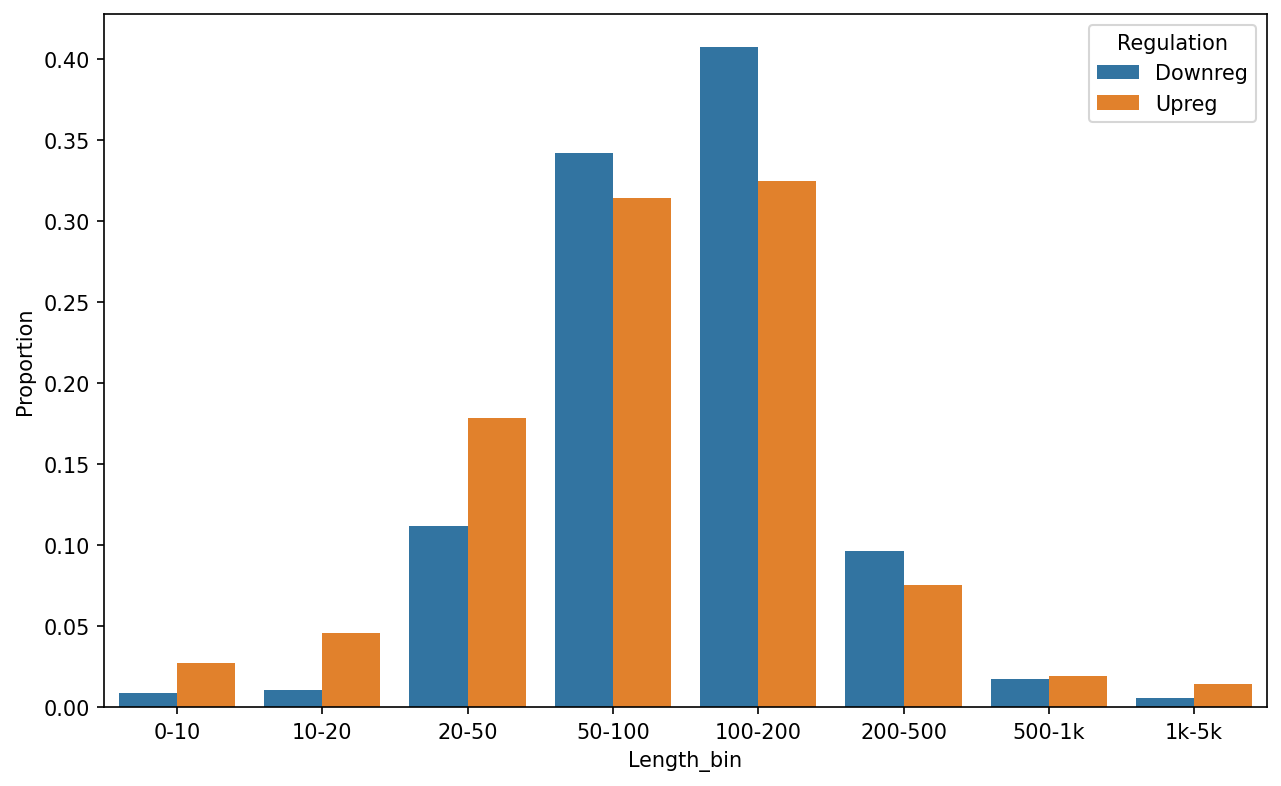

In [19]:
# Proportions within each Regulation group

psi_corr_df_coords_filt = psi_corr_df_coords[psi_corr_df_coords['Regulation'] != "None"]

psi_corr_df_coords_filt['Length_bin'] = pd.cut(psi_corr_df_coords_filt['Length'], 
                                                bins=[0, 10, 20, 50, 100, 200, 500, 1000, 5000],
                                                labels=['0-10', '10-20', '20-50', '50-100', '100-200', '200-500', '500-1k', '1k-5k'])

ct = psi_corr_df_coords_filt.groupby(['Regulation', 'Length_bin']).size()
props = ct.groupby(level=0).transform(lambda x: x / x.sum()).reset_index(name='Proportion')

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
sns.barplot(data=props, x='Length_bin', y='Proportion', hue='Regulation', ax=ax)
plt.show()

## Compare hits to previously reported exons

In [20]:
psi_corr_df_coords['My_coords'] = psi_corr_df_coords['exon_start'].astype(str) + "-" + psi_corr_df_coords['exon_end'].astype(str)
exons['Their_coords'] = exons['start'].astype(str) + "-" + exons['end'].astype(str)

In [21]:
shared_exons_df = psi_corr_df_coords.merge(exons, left_on="My_coords", right_on="Their_coords")
shared_exons_df.shape

(1433, 27)

In [22]:
exons.shape

(2587, 9)

In [23]:
mask_upreg = shared_exons_df['Regulation'] == "Upreg"
shared_exons_df[mask_upreg].value_counts("Neural Regulation")

Neural Regulation
NEURAL-UP      643
NEURAL-DOWN     17
Name: count, dtype: int64

In [24]:
mask_downreg = shared_exons_df['Regulation'] == "Downreg"
shared_exons_df[mask_downreg].value_counts("Neural Regulation")

Neural Regulation
NEURAL-DOWN    208
NEURAL-UP       16
Name: count, dtype: int64

/tmp/ipykernel_1560421/3828180236.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct = shared_exons_df_filt.groupby(['Regulation', 'Length_bin']).size()


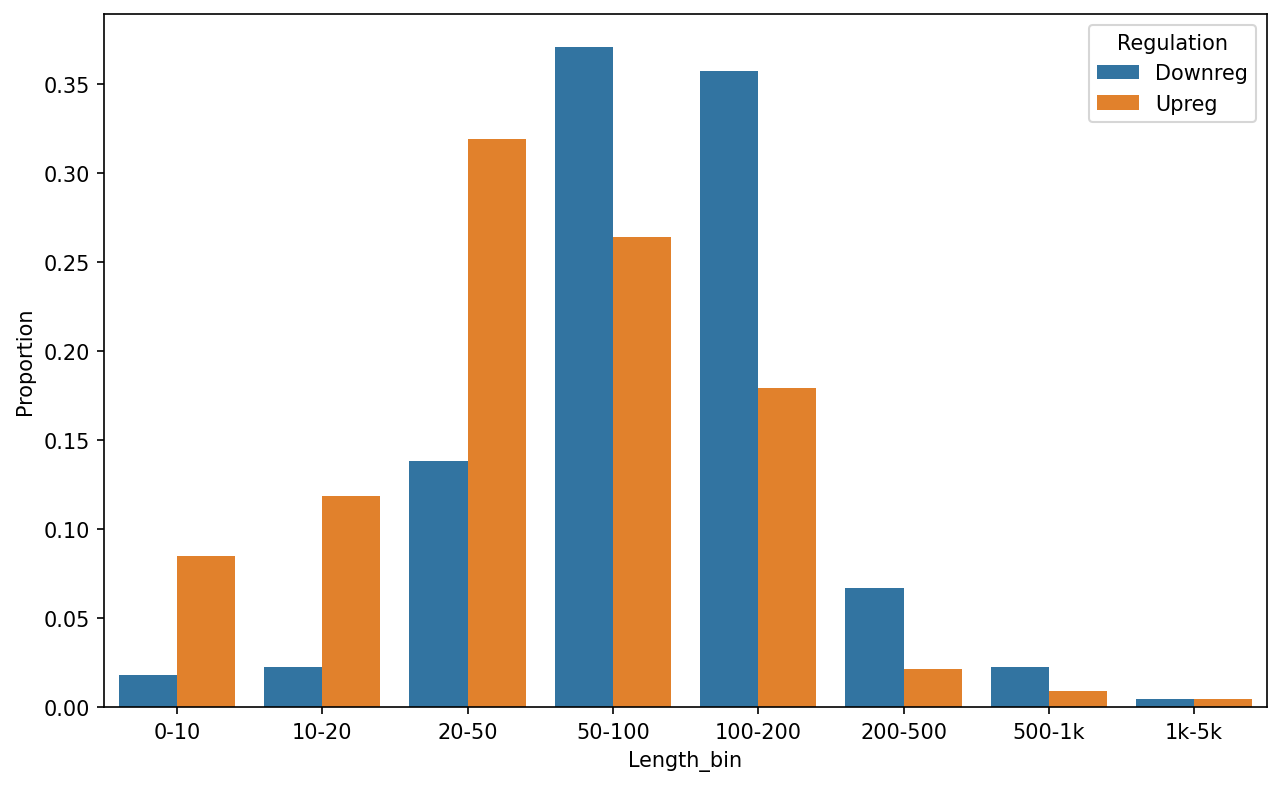

In [25]:
shared_exons_df['Length_bin'] = pd.cut(shared_exons_df['Length'], 
                                       bins=[0, 10, 20, 50, 100, 200, 500, 1000, 5000],
                                       labels=['0-10', '10-20', '20-50', '50-100', '100-200', '200-500', '500-1k', '1k-5k'])

shared_exons_df_filt = shared_exons_df[shared_exons_df['Regulation'] != "None"]

ct = shared_exons_df_filt.groupby(['Regulation', 'Length_bin']).size()
props = ct.groupby(level=0).transform(lambda x: x / x.sum()).reset_index(name='Proportion')

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
sns.barplot(data=props, x='Length_bin', y='Proportion', hue='Regulation', ax=ax)
plt.show()